In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


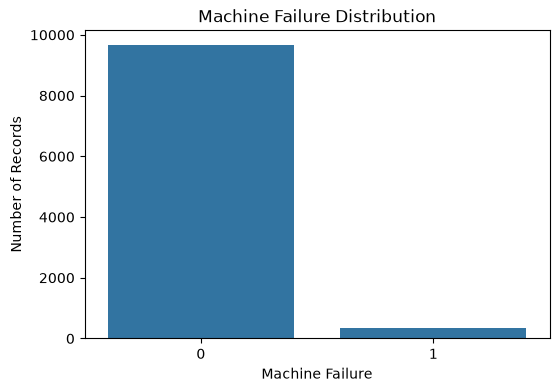

In [3]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Machine failure")

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Records")

plt.show()

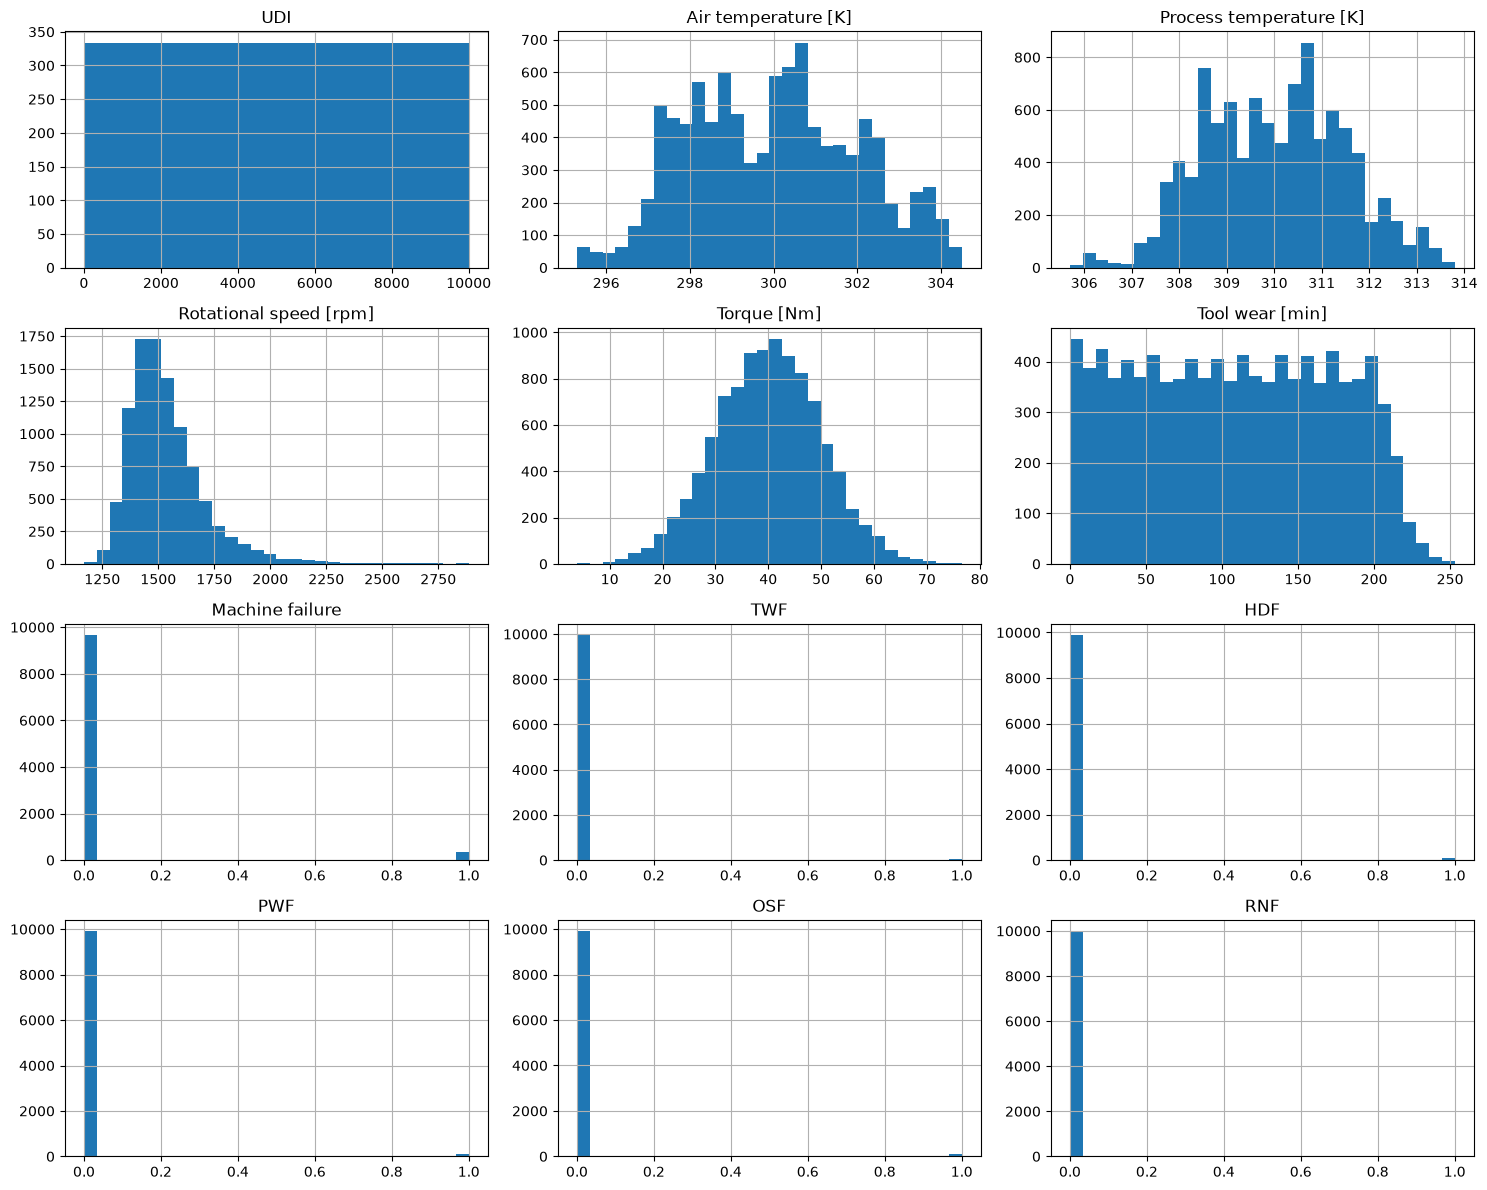

In [4]:
df.hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

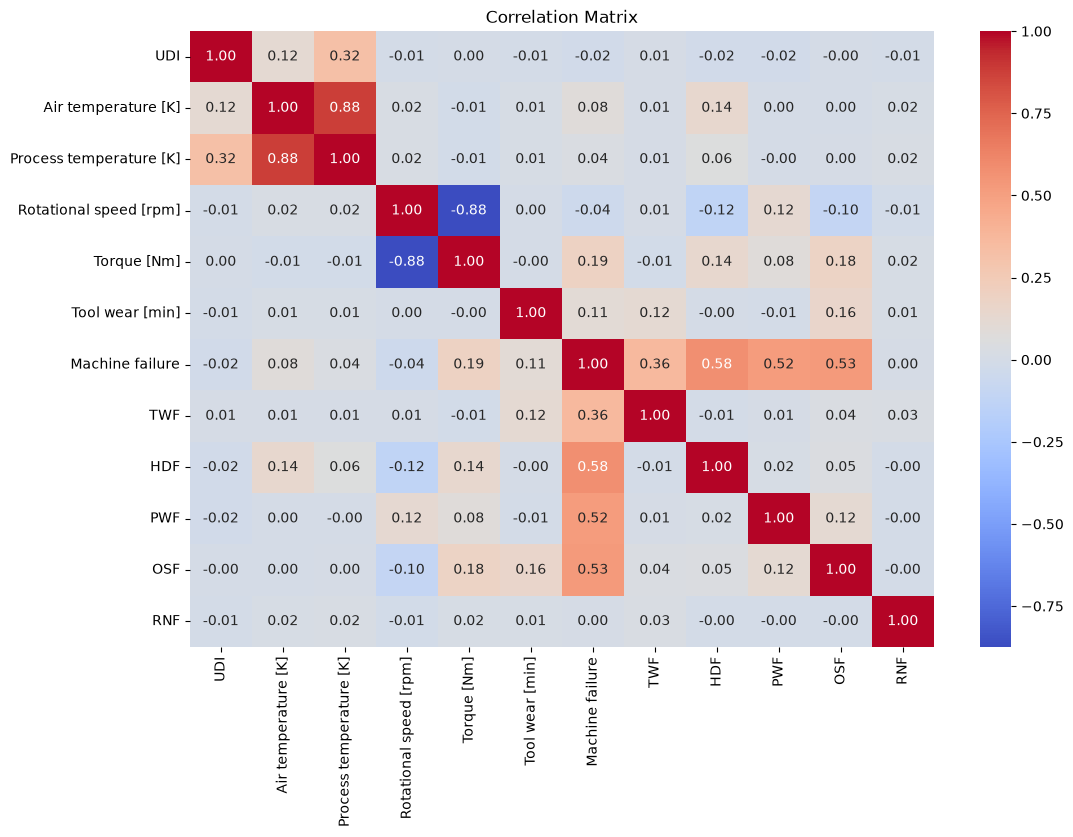

In [5]:
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

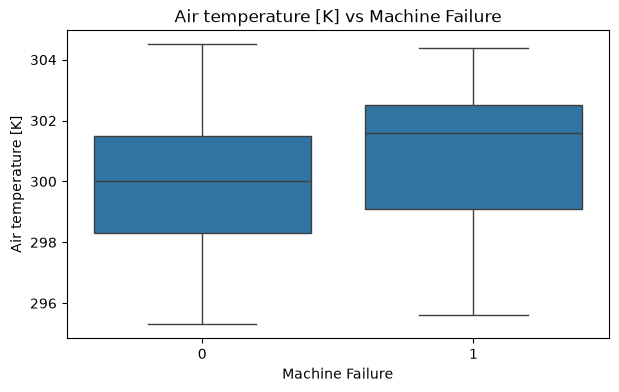

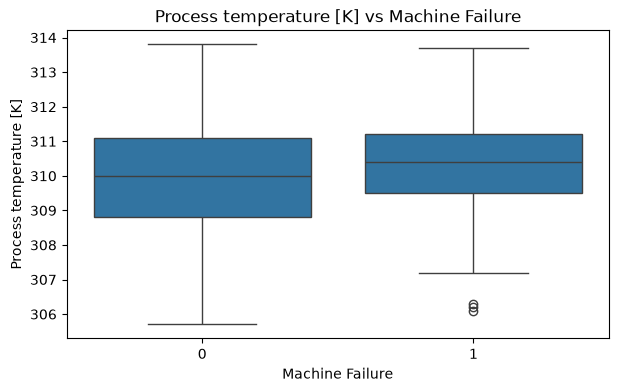

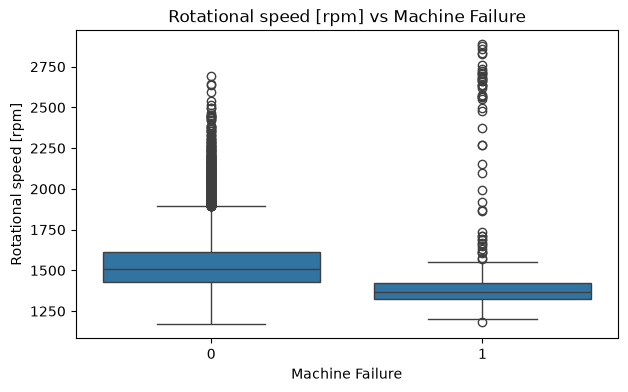

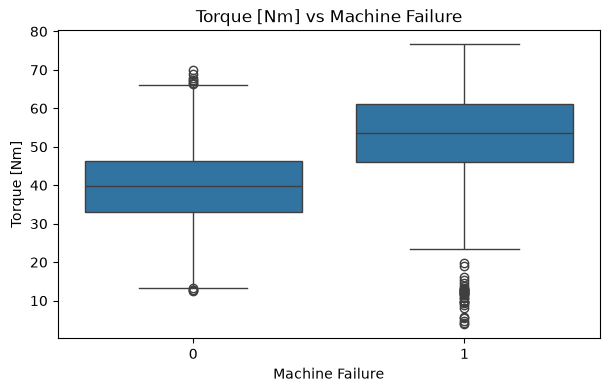

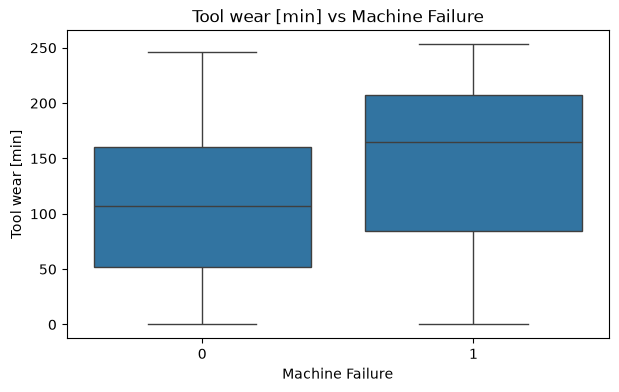

In [6]:
sensor_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for column in sensor_columns:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="Machine failure",
        y=column
    )

    plt.title(f"{column} vs Machine Failure")
    plt.xlabel("Machine Failure")
    plt.ylabel(column)

    plt.show()

In [7]:
sensor_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

failure_comparison = df.groupby("Machine failure")[sensor_columns].mean()

failure_comparison

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


In [8]:
difference = failure_comparison.loc[1] - failure_comparison.loc[0]

print("Average difference between failed and normal machines:")
print(difference)

Average difference between failed and normal machines:
Air temperature [K]         0.912432
Process temperature [K]     0.294696
Rotational speed [rpm]    -43.773289
Torque [Nm]                10.538486
Tool wear [min]            37.087994
dtype: float64


In [9]:
failure_by_type = pd.crosstab(
    df["Type"],
    df["Machine failure"],
    normalize="index"
) * 100

failure_by_type

Machine failure,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


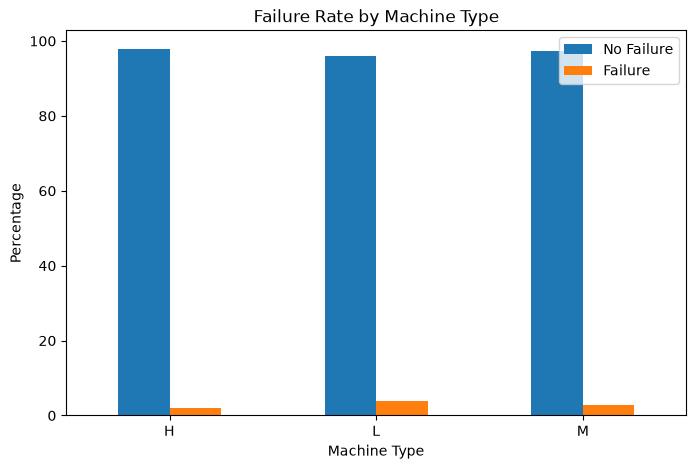

In [10]:
failure_by_type.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Failure Rate by Machine Type")
plt.xlabel("Machine Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["No Failure", "Failure"])

plt.show()

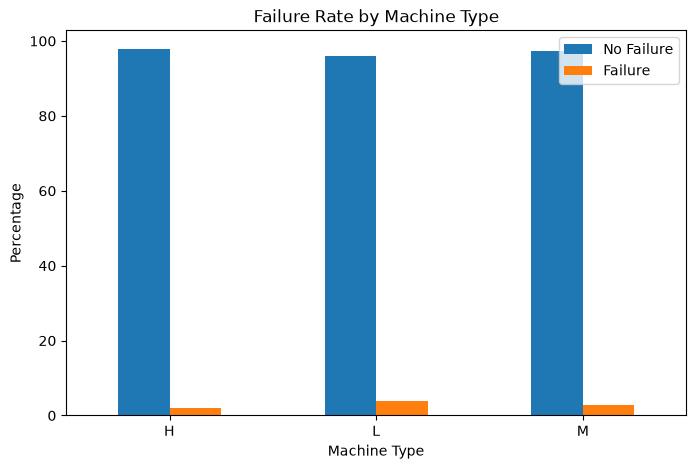

In [11]:
failure_by_type.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Failure Rate by Machine Type")
plt.xlabel("Machine Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["No Failure", "Failure"])

plt.show()